# Predicción de la deserción estudiantil con MLP y Self-Attention

## Proyecto final de Deep Learning

Se realizó una apliación de un Multilayer Perceptron (MLP) con un Self-Attentionpara identificar estudiantes con riesgo de abandono. El análisis se concentra en la clase minoritaria, que representa el 3,14 % de los registros; por ello, PR-AUC, precision, recall y F1 son más informativas que la accuracy por sí sola.

El diseño evita fuga de información: `id_estudiante` y las columnas constantes se excluyen, el preprocesamiento se aprende únicamente con entrenamiento, el umbral se selecciona en validación y la comparación final se realiza sobre prueba.


## Introducción
La ejecución registrada utiliza 500.000 observaciones, de las cuales 15.700 corresponden a abandono y 484.300 a no abandono. En el conjunto de prueba, la MLP alcanzó PR-AUC de 0,8064 y F1 de 0,7900, mientras que el Self-Attention model obtuvo PR-AUC de 0,8036 y F1 de 0,7862.

La diferencia es pequeña, pero consistente a favor de la MLP en las métricas enfocadas en la clase positiva. Además, la MLP detectó seis abandonos más y generó trece alertas falsas menos. El Self-Attention model solo presentó una ventaja marginal en ROC-AUC, de 0,0005, que no se tradujo en una mejor clasificación al umbral seleccionado. Por desempeño y simplicidad, la MLP es la alternativa preferible en esta ejecución.

Los pesos de atención no revelaron una jerarquía fuerte entre variables. `inasistencia_anual_pct` sobresalió de manera moderada, pero este resultado describe una asociación aprendida por el modelo y no una relación causal.


## Resumen de arquitectura

### Por qué se escogieron estas arquitecturas

El **Multilayer Perceptron (MLP)** se escogió como línea base porque funciona bien con datos tabulares y puede aprender relaciones no lineales entre variables numéricas y categóricas. El **Self-Attention model** se incluyó para comprobar si modelar explícitamente las relaciones entre variables —por ejemplo, entre inasistencia, calificaciones y materias reprobadas— aportaba una ventaja frente a la concatenación directa de la MLP. Ambos modelos reciben las mismas variables y las representan con vectores de dimensión 32, de modo que la comparación se concentra en la forma de combinar la información.

### Estructura del Multilayer Perceptron

La entrada contiene ocho variables numéricas y cinco categóricas. Cada variable numérica pasa por una proyección `Dense` de dimensión 32 y cada variable categórica por un `Embedding` de la misma dimensión. Los trece vectores se concatenan en una representación de 416 componentes. El clasificador procesa ese vector mediante capas `Dense` de 128, 64 y 32 unidades con activación ReLU. `BatchNormalization` estabiliza la primera capa oculta y `Dropout` de 0,30 y 0,20 reduce el riesgo de sobreajuste. Una neurona final con activación `sigmoid` genera la puntuación de abandono. Esta red tiene 65.761 parámetros.

### Estructura del Self-Attention model

Las mismas trece representaciones se apilan como una secuencia de forma `13 × 32`. Un bloque `MultiHeadAttention` con cuatro cabezas permite que cada variable consulte a las demás desde distintos subespacios de dimensión ocho. La salida se combina con la entrada mediante una conexión residual y `LayerNormalization`. Después, una red feed-forward transforma cada token de 32 a 64 componentes y nuevamente a 32, seguida de otra conexión residual y normalización. `GlobalAveragePooling1D` resume los trece tokens, una capa `Dense` de 64 unidades realiza la clasificación intermedia y una salida `sigmoid` produce la puntuación final. Este modelo tiene 12.225 parámetros; aunque incorpora un mecanismo más especializado, posee menos parámetros que la MLP.

### Recorrido del forward pass

En el `forward pass`, un lote entra primero al bloque de representación. Las variables numéricas estandarizadas se proyectan y las categorías se convierten en embeddings. En la MLP, todos los vectores se concatenan y avanzan por las capas densas hasta obtener la salida `sigmoid`. En el Self-Attention model, los vectores interactúan mediante consultas, claves y valores; luego se resumen y se clasifican. Durante la inferencia, el resultado es una puntuación continua. Esa puntuación se compara con el umbral aprendido en validación —0,9197 para la MLP y 0,9515 para el Self-Attention model— para asignar la clase final.

Durante el entrenamiento, la salida se compara con la etiqueta mediante `Binary Cross-Entropy`. El error ponderado se propaga hacia atrás y Adam actualiza los parámetros. Los pesos de clase hacen que equivocarse en un caso de abandono tenga más influencia que equivocarse en un caso de no abandono.

### Lectura de las gráficas de training loss y validation loss

La gráfica de pérdida muestra cuánto error comete el modelo: una reducción indica aprendizaje, mientras que una separación creciente entre entrenamiento y validación puede indicar sobreajuste. En este experimento, la `training loss` no debe compararse de manera literal con la `validation loss`, porque los pesos de clase y el Dropout actúan durante entrenamiento, mientras la pérdida de validación se calcula sin esas mismas condiciones. Por eso es posible observar una `validation loss` inferior sin que exista un problema metodológico.

La MLP continuó mejorando gradualmente y alcanzó su mejor `validation PR-AUC` en la época 18, con 0,8039. El entrenamiento se detuvo en la época 22 y restauró esos pesos. El Self-Attention model aprendió más rápido, alcanzó su mejor `validation PR-AUC` en la época 5, con 0,7989, y se detuvo en la época 9. Después de sus mejores épocas, ambas métricas oscilaron sin una mejora sostenida, lo que justifica el uso de `EarlyStopping` y `ReduceLROnPlateau`.

Las curvas no muestran un sobreajuste severo. La MLP presenta una evolución más estable, mientras el Self-Attention model llega pronto a una meseta. El resultado de prueba confirma esa lectura: los valores de PR-AUC permanecen próximos a los obtenidos en validación.

### Cómo explicar los resultados

La MLP alcanzó PR-AUC de 0,8064, recall de 0,7707 y F1 de 0,7900. El Self-Attention model obtuvo PR-AUC de 0,8036, recall de 0,7682 y F1 de 0,7862. La diferencia es pequeña, pero la atención no mejoró la línea base. La MLP detectó 1.815 de los 2.355 abandonos reales, mientras el Self-Attention model detectó 1.809. Además, la MLP produjo 425 falsas alarmas frente a 438.

La conclusión defendible es que la MLP fue seleccionada porque ofreció el mejor desempeño práctico con un flujo arquitectónico más directo. El Self-Attention model era una hipótesis razonable para capturar interacciones entre variables, pero los resultados demuestran que una arquitectura más especializada no garantiza una mejora. En este conjunto, las capas densas fueron suficientes para representar las relaciones predictivas principales.

### Respuesta breve para una defensa

> Se comparó una MLP como línea base para datos tabulares con un Self-Attention model diseñado para aprender interacciones explícitas entre las variables. En el forward pass, ambas redes transforman cada predictor en un vector de 32 dimensiones; la MLP concatena esos vectores y los procesa con capas densas, mientras el segundo modelo aplica atención de cuatro cabezas, conexiones residuales y una red feed-forward. Las curvas muestran aprendizaje estable y detención temprana antes de un sobreajuste marcado. La MLP obtuvo PR-AUC de 0,8064 y F1 de 0,7900, ligeramente superiores a los valores de 0,8036 y 0,7862 del Self-Attention model. Por eso se escogió la MLP: produjo mejores resultados con una ruta de procesamiento más simple.


In [33]:

# En Google Colab, quita el símbolo # de la siguiente línea si hace falta instalar:
# !pip -q install pandas openpyxl scikit-learn tensorflow matplotlib joblib pyarrow

## Configuración reproducible

La semilla fija reduce la variación asociada con la partición de los datos y la inicialización de los pesos. Aun así, pequeñas diferencias entre equipos, versiones de las bibliotecas o aceleradores pueden modificar ligeramente los resultados.


In [7]:

import os
import re
import json
import random
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Semilla:", SEED)


TensorFlow: 2.15.0
Semilla: 42


In [8]:
FILE_PATH = Path("/home/jcastillo/datos_desercion_fiscal_v3_500k_con_ruido.csv")
TARGET = "abandono"

# Ejecución reproducible de referencia con 100.000 filas.
# Cambia a False para utilizar los 500.000 registros.
MODO_PRUEBA = False
FILAS_PRUEBA = 100_000

# Variables que no deben entrar al modelo.
ID_COLUMNS = ["id_estudiante"]

NROWS = FILAS_PRUEBA if MODO_PRUEBA else None

print("Archivo:", FILE_PATH)
print("Objetivo:", TARGET)
print("Filas a leer:", NROWS if NROWS is not None else "todas")


Archivo: /home/jcastillo/datos_desercion_fiscal_v3_500k_con_ruido.csv
Objetivo: abandono
Filas a leer: todas


In [9]:
# OPCIONAL PARA GOOGLE COLAB:
# from google.colab import files
# uploaded = files.upload()
# FILE_PATH = next(iter(uploaded))

file_path = Path(FILE_PATH)

if not file_path.exists():
    raise FileNotFoundError(
        f"No se encontró '{file_path}'. "
        "Sube el archivo a Colab o revisa la ruta."
    )

extension = file_path.suffix.lower()
parquet_path = file_path.with_suffix(".parquet")

if parquet_path.exists() and not MODO_PRUEBA:
    print("Leyendo la copia Parquet...")
    df = pd.read_parquet(parquet_path)

elif extension == ".csv":
    print("Leyendo el archivo CSV...")
    df = pd.read_csv(
        file_path,
        nrows=NROWS,
        low_memory=False,
    )

elif extension in {".xlsx", ".xls"}:
    print("Leyendo el archivo Excel. Puede tardar...")
    df = pd.read_excel(
        file_path,
        engine="openpyxl",
        nrows=NROWS,
    )

elif extension == ".parquet":
    print("Leyendo el archivo Parquet...")
    df = pd.read_parquet(file_path)

else:
    raise ValueError(
        f"Formato no compatible: {extension}. "
        "Utiliza CSV, XLSX, XLS o Parquet."
    )

# Crear una copia rápida en Parquet.
if extension != ".parquet" and not MODO_PRUEBA:
    try:
        df.to_parquet(parquet_path, index=False)
        print("Copia rápida guardada en:", parquet_path)
    except Exception as error:
        print("No se pudo crear la copia Parquet.")
        print("Detalle:", error)

print("Archivo cargado:", file_path.name)
print("Dimensión del dataset:", df.shape)
display(df.head())

Leyendo la copia Parquet...
Copia rápida guardada en: /home/jcastillo/datos_desercion_fiscal_v3_500k_con_ruido.parquet
Archivo cargado: datos_desercion_fiscal_v3_500k_con_ruido.csv
Dimensión del dataset: (500000, 16)


,id_estudiante,sexo,edad_cronologica,edad_esperada,grado,zona_geografica,tipo_institucion,nacionalidad,indice_pobreza,repeticion_previa,calificacion_anual,materias_reprobadas,inasistencia_anual_pct,reportes_disciplinarios,inseguridad_violencia_plantel,abandono
0,1,Femenino,16.0,13.0,9no EGB,Urbana,Fiscal,Ecuatoriana,Q1,1.0,4.362978,2.0,7.924168,NaN,0.0,0
1,2,Masculino,17.0,17.0,3ro BGU,None,Fiscal,Ecuatoriana,Q1,0.0,8.549958,1.0,4.442279,1.0,0.0,0
2,3,Masculino,16.0,16.0,2do BGU,Rural,Fiscal,Ecuatoriana,Q3,0.0,6.292625,6.0,15.767553,5.0,0.0,0
3,4,Femenino,15.0,15.0,1ro BGU,None,Fiscal,Ecuatoriana,Q2,0.0,7.540213,0.0,6.238403,0.0,0.0,0
4,5,Femenino,12.0,12.0,8vo EGB,Rural,Fiscal,Ecuatoriana,Q1,0.0,4.553580,5.0,21.296135,0.0,1.0,0


## Exploración y control de calidad

La revisión inicial permite comprobar la estructura del conjunto, los tipos de datos, la presencia de valores faltantes, los duplicados y la distribución de la variable objetivo antes de entrenar los modelos.


In [10]:

print("Columnas:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i:02d}. {column}")

print("\nTipos de datos:")
display(df.dtypes.to_frame("tipo"))

print("\nValores faltantes por columna:")
missing = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .to_frame("faltantes")
)
missing["porcentaje"] = 100 * missing["faltantes"] / len(df)
display(missing)

print("\nFilas duplicadas:", df.duplicated().sum())

if TARGET not in df.columns:
    raise KeyError(
        f"No existe la columna objetivo '{TARGET}'. "
        f"Revisa la lista de columnas y modifica TARGET."
    )

print("\nValores originales del objetivo:")
display(df[TARGET].value_counts(dropna=False).to_frame("cantidad"))


Columnas:
01. id_estudiante
02. sexo
03. edad_cronologica
04. edad_esperada
05. grado
06. zona_geografica
07. tipo_institucion
08. nacionalidad
09. indice_pobreza
10. repeticion_previa
11. calificacion_anual
12. materias_reprobadas
13. inasistencia_anual_pct
14. reportes_disciplinarios
15. inseguridad_violencia_plantel
16. abandono

Tipos de datos:


,tipo
id_estudiante,int64
sexo,object
edad_cronologica,float64
edad_esperada,float64
grado,object
zona_geografica,object
tipo_institucion,object
nacionalidad,object
indice_pobreza,object
repeticion_previa,float64



Valores faltantes por columna:


,faltantes,porcentaje
materias_reprobadas,10049,2.0098
calificacion_anual,10036,2.0072
edad_cronologica,10018,2.0036
repeticion_previa,10012,2.0024
inasistencia_anual_pct,9993,1.9986
grado,9936,1.9872
zona_geografica,9931,1.9862
edad_esperada,9914,1.9828
sexo,9881,1.9762
inseguridad_violencia_plantel,9880,1.9760



Filas duplicadas: 0

Valores originales del objetivo:


,cantidad
abandono,
0,484300
1,15700


In [34]:

def limpiar_objetivo(serie: pd.Series) -> pd.Series:
    """Convierte una variable binaria común a enteros 0 y 1."""

    if serie.isna().any():
        print("Se eliminarán filas con objetivo vacío:", int(serie.isna().sum()))

    serie_no_nula = serie.dropna()

    # Intento 1: valores numéricos 0 y 1.
    numerica = pd.to_numeric(serie_no_nula, errors="coerce")
    if numerica.notna().all() and set(numerica.unique()).issubset({0, 1}):
        salida = pd.to_numeric(serie, errors="coerce")
        return salida.astype("Int64")

    # Intento 2: etiquetas escritas.
    texto = (
        serie.astype("string")
             .str.strip()
             .str.lower()
             .str.normalize("NFKD")
             .str.encode("ascii", errors="ignore")
             .str.decode("utf-8")
    )

    mapa = {
        "1": 1,
        "1.0": 1,
        "si": 1,
        "yes": 1,
        "true": 1,
        "abandono": 1,
        "abandona": 1,
        "abandono fiscal": 1,
        "desercion": 1,
        "deserta": 1,
        "positivo": 1,

        "0": 0,
        "0.0": 0,
        "no": 0,
        "false": 0,
        "no abandono": 0,
        "no abandona": 0,
        "continua": 0,
        "permanece": 0,
        "negativo": 0,
    }

    salida = texto.map(mapa)

    valores_no_reconocidos = (
        serie[salida.isna() & serie.notna()]
        .astype(str)
        .unique()
        .tolist()
    )

    if valores_no_reconocidos:
        raise ValueError(
            "Hay etiquetas del objetivo que no fueron reconocidas: "
            f"{valores_no_reconocidos[:20]}. "
            "Agrégalas al diccionario 'mapa' de esta función."
        )

    return salida.astype("Int64")


# Eliminamos solamente las filas cuyo objetivo está vacío.
df = df[df[TARGET].notna()].copy()
df[TARGET] = limpiar_objetivo(df[TARGET]).astype("int32")

print("Objetivo limpio:")
display(df[TARGET].value_counts().sort_index().to_frame("cantidad"))


Objetivo limpio:


,cantidad
abandono,
0,484300
1,15700


## Distribución de la variable objetivo

La clase de abandono representa únicamente el 3,14 % de los datos. Esta desproporción justifica el uso de pesos de clase durante el entrenamiento y de métricas sensibles al desempeño sobre la clase positiva.


,clase,cantidad,porcentaje
0,No abandono (0),484300,96.86
1,Abandono (1),15700,3.14


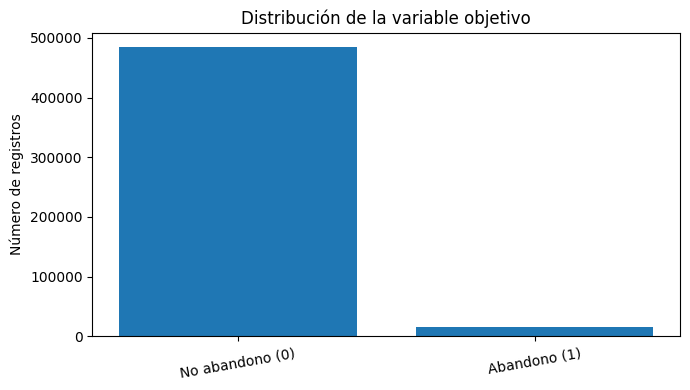

In [12]:

class_counts = df[TARGET].value_counts().sort_index()
class_percent = 100 * class_counts / class_counts.sum()

resumen_clases = pd.DataFrame({
    "clase": ["No abandono (0)", "Abandono (1)"],
    "cantidad": [class_counts.get(0, 0), class_counts.get(1, 0)],
    "porcentaje": [class_percent.get(0, 0), class_percent.get(1, 0)],
})

display(resumen_clases)

plt.figure(figsize=(7, 4))
plt.bar(resumen_clases["clase"], resumen_clases["cantidad"])
plt.title("Distribución de la variable objetivo")
plt.ylabel("Número de registros")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()


In [35]:
possible_ids = [
    c for c in df.columns
    if c != TARGET and (
        c.lower() == "id"
        or c.lower().startswith("id_")
        or c.lower().endswith("_id")
        or "documento" in c.lower()
        or "identificacion" in c.lower()
    )
]

constant_columns = [
    c for c in df.columns
    if c != TARGET and df[c].nunique(dropna=False) <= 1
]

columns_to_drop = list(dict.fromkeys(
    [TARGET]
    + [c for c in ID_COLUMNS if c in df.columns]
    + constant_columns
))

print("Posibles identificadores:", possible_ids)
print("Identificadores excluidos:", ID_COLUMNS)
print("Columnas constantes excluidas:", constant_columns)

X = df.drop(columns=columns_to_drop).copy()
y = df[TARGET].copy()

print("Variables de entrada:", X.shape[1])
print("Registros:", X.shape[0])
display(X.head())


Posibles identificadores: ['id_estudiante']
Identificadores excluidos: ['id_estudiante']
Columnas constantes excluidas: ['tipo_institucion']
Variables de entrada: 13
Registros: 500000


,sexo,edad_cronologica,edad_esperada,grado,zona_geografica,nacionalidad,indice_pobreza,repeticion_previa,calificacion_anual,materias_reprobadas,inasistencia_anual_pct,reportes_disciplinarios,inseguridad_violencia_plantel
0,Femenino,16.0,13.0,9no EGB,Urbana,Ecuatoriana,Q1,1.0,4.362978,2.0,7.924168,NaN,0.0
1,Masculino,17.0,17.0,3ro BGU,None,Ecuatoriana,Q1,0.0,8.549958,1.0,4.442279,1.0,0.0
2,Masculino,16.0,16.0,2do BGU,Rural,Ecuatoriana,Q3,0.0,6.292625,6.0,15.767553,5.0,0.0
3,Femenino,15.0,15.0,1ro BGU,None,Ecuatoriana,Q2,0.0,7.540213,0.0,6.238403,0.0,0.0
4,Femenino,12.0,12.0,8vo EGB,Rural,Ecuatoriana,Q1,0.0,4.553580,5.0,21.296135,0.0,1.0


## Partición de los datos

Los datos se distribuyen de forma estratificada: 70 % para entrenamiento, 15 % para validación y 15 % para prueba. El modelo aprende sus parámetros con entrenamiento; validación controla la detención temprana y permite seleccionar el umbral; prueba se reserva para estimar el desempeño final. La estratificación conserva una prevalencia de abandono cercana al 3,14 % en los tres subconjuntos.


In [14]:

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp,
)

def resumen_particion(nombre, X_part, y_part):
    positivos = int(y_part.sum())
    total = len(y_part)
    porcentaje = 100 * positivos / total
    print(
        f"{nombre:15s} | filas: {total:>8,} | "
        f"abandono: {positivos:>7,} ({porcentaje:.2f} %)"
    )

resumen_particion("Entrenamiento", X_train, y_train)
resumen_particion("Validación", X_val, y_val)
resumen_particion("Prueba", X_test, y_test)


Entrenamiento   | filas:  350,000 | abandono:  10,990 (3.14 %)
Validación      | filas:   75,000 | abandono:   2,355 (3.14 %)
Prueba          | filas:   75,000 | abandono:   2,355 (3.14 %)


## Tipos de variables

El conjunto de entrada contiene ocho variables numéricas y cinco categóricas. Las numéricas se imputan con la mediana y se estandarizan. Las categóricas se convierten a texto, reciben una categoría explícita cuando falta información, se codifican con enteros y se representan mediante embeddings aprendidos por la red.


In [15]:

numeric_columns = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_columns = [c for c in X_train.columns if c not in numeric_columns]

print("Variables numéricas:", len(numeric_columns))
print(numeric_columns)

print("\nVariables categóricas:", len(categorical_columns))
print(categorical_columns)

if len(numeric_columns) + len(categorical_columns) == 0:
    raise ValueError("No quedaron variables de entrada.")


Variables numéricas: 8
['edad_cronologica', 'edad_esperada', 'repeticion_previa', 'calificacion_anual', 'materias_reprobadas', 'inasistencia_anual_pct', 'reportes_disciplinarios', 'inseguridad_violencia_plantel']

Variables categóricas: 5
['sexo', 'grado', 'zona_geografica', 'nacionalidad', 'indice_pobreza']


## Preprocesamiento sin fuga de información

Todos los transformadores se ajustan exclusivamente con el conjunto de entrenamiento. De este modo, las medianas, escalas y categorías observadas en validación y prueba no influyen en el aprendizaje. Las categorías conocidas reciben códigos enteros y cualquier categoría no observada durante el ajuste se dirige al código reservado para valores desconocidos.


In [16]:

# ---------- Variables numéricas ----------
numeric_imputer = SimpleImputer(strategy="median")
numeric_scaler = StandardScaler()

if numeric_columns:
    X_train_num = numeric_imputer.fit_transform(
        X_train[numeric_columns].apply(pd.to_numeric, errors="coerce")
    )
    X_val_num = numeric_imputer.transform(
        X_val[numeric_columns].apply(pd.to_numeric, errors="coerce")
    )
    X_test_num = numeric_imputer.transform(
        X_test[numeric_columns].apply(pd.to_numeric, errors="coerce")
    )

    X_train_num = numeric_scaler.fit_transform(X_train_num).astype("float32")
    X_val_num = numeric_scaler.transform(X_val_num).astype("float32")
    X_test_num = numeric_scaler.transform(X_test_num).astype("float32")
else:
    X_train_num = np.empty((len(X_train), 0), dtype="float32")
    X_val_num = np.empty((len(X_val), 0), dtype="float32")
    X_test_num = np.empty((len(X_test), 0), dtype="float32")


# ---------- Variables categóricas ----------
categorical_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1,
)

def preparar_categoricas(dataframe, columns):
    if not columns:
        return pd.DataFrame(index=dataframe.index)

    salida = dataframe[columns].copy()
    for column in columns:
        salida[column] = (
            salida[column]
            .astype("string")
            .fillna("__FALTANTE__")
        )
    return salida

if categorical_columns:
    train_cat_df = preparar_categoricas(X_train, categorical_columns)
    val_cat_df = preparar_categoricas(X_val, categorical_columns)
    test_cat_df = preparar_categoricas(X_test, categorical_columns)

    X_train_cat = categorical_encoder.fit_transform(train_cat_df)
    X_val_cat = categorical_encoder.transform(val_cat_df)
    X_test_cat = categorical_encoder.transform(test_cat_df)

    # El encoder usa -1 para desconocidos. Sumamos 1:
    # desconocido = 0; categorías conocidas = 1, 2, 3, ...
    X_train_cat = (X_train_cat + 1).astype("int32")
    X_val_cat = (X_val_cat + 1).astype("int32")
    X_test_cat = (X_test_cat + 1).astype("int32")

    categorical_vocab_sizes = [
        len(categories) + 1
        for categories in categorical_encoder.categories_
    ]
else:
    X_train_cat = np.empty((len(X_train), 0), dtype="int32")
    X_val_cat = np.empty((len(X_val), 0), dtype="int32")
    X_test_cat = np.empty((len(X_test), 0), dtype="int32")
    categorical_vocab_sizes = []

print("Matriz numérica de entrenamiento:", X_train_num.shape)
print("Matriz categórica de entrenamiento:", X_train_cat.shape)
print("Tamaños de vocabulario:", categorical_vocab_sizes)


Matriz numérica de entrenamiento: (350000, 8)
Matriz categórica de entrenamiento: (350000, 5)
Tamaños de vocabulario: [4, 8, 6, 6, 7]


## Entradas para TensorFlow

Cada variable se entrega al modelo como una entrada independiente. Las variables numéricas usan nombres del tipo `num_0` y las categóricas del tipo `cat_0`. Esta organización permite construir una representación vectorial por columna y tratar cada variable como un token dentro del bloque de Self-Attention.


In [17]:

def crear_diccionario_entradas(num_array, cat_array):
    inputs = {}

    for i in range(num_array.shape[1]):
        inputs[f"num_{i}"] = num_array[:, i:i+1]

    for i in range(cat_array.shape[1]):
        inputs[f"cat_{i}"] = cat_array[:, i:i+1]

    return inputs


train_inputs = crear_diccionario_entradas(X_train_num, X_train_cat)
val_inputs = crear_diccionario_entradas(X_val_num, X_val_cat)
test_inputs = crear_diccionario_entradas(X_test_num, X_test_cat)

y_train_np = y_train.to_numpy(dtype="float32")
y_val_np = y_val.to_numpy(dtype="float32")
y_test_np = y_test.to_numpy(dtype="float32")

print("Entradas creadas:", list(train_inputs.keys()))


Entradas creadas: ['num_0', 'num_1', 'num_2', 'num_3', 'num_4', 'num_5', 'num_6', 'num_7', 'cat_0', 'cat_1', 'cat_2', 'cat_3', 'cat_4']


## Canalización con `tf.data`

`tf.data` organiza los registros en lotes y prepara el siguiente lote mientras se procesa el actual. Se utiliza un tamaño de lote de 1024 para aprovechar la GPU; si el equipo no dispone de memoria suficiente, este valor puede reducirse sin alterar la lógica del experimento.


In [18]:

BATCH_SIZE = 1024

def crear_dataset(inputs, labels, training=False):
    dataset = tf.data.Dataset.from_tensor_slices((inputs, labels))

    if training:
        dataset = dataset.shuffle(
            buffer_size=min(len(labels), 100_000),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

train_ds = crear_dataset(train_inputs, y_train_np, training=True)
val_ds = crear_dataset(val_inputs, y_val_np)
test_ds = crear_dataset(test_inputs, y_test_np)

print(train_ds)


<_PrefetchDataset element_spec=({'num_0': TensorSpec(shape=(None, 1), dtype=tf.float32, name=None), 'num_1': TensorSpec(shape=(None, 1), dtype=tf.float32, name=None), 'num_2': TensorSpec(shape=(None, 1), dtype=tf.float32, name=None), 'num_3': TensorSpec(shape=(None, 1), dtype=tf.float32, name=None), 'num_4': TensorSpec(shape=(None, 1), dtype=tf.float32, name=None), 'num_5': TensorSpec(shape=(None, 1), dtype=tf.float32, name=None), 'num_6': TensorSpec(shape=(None, 1), dtype=tf.float32, name=None), 'num_7': TensorSpec(shape=(None, 1), dtype=tf.float32, name=None), 'cat_0': TensorSpec(shape=(None, 1), dtype=tf.int32, name=None), 'cat_1': TensorSpec(shape=(None, 1), dtype=tf.int32, name=None), 'cat_2': TensorSpec(shape=(None, 1), dtype=tf.int32, name=None), 'cat_3': TensorSpec(shape=(None, 1), dtype=tf.int32, name=None), 'cat_4': TensorSpec(shape=(None, 1), dtype=tf.int32, name=None)}, TensorSpec(shape=(None,), dtype=tf.float32, name=None))>


## Tratamiento del desbalance

La función de pérdida asigna mayor peso a los errores de la clase minoritaria. Con la distribución observada, el peso del abandono es aproximadamente 15,92 y el de no abandono 0,52. Este procedimiento no crea observaciones sintéticas: modifica la contribución de cada clase al aprendizaje para evitar que el modelo privilegie la clase mayoritaria.


In [19]:

negative_count = int((y_train_np == 0).sum())
positive_count = int((y_train_np == 1).sum())
total_count = negative_count + positive_count

class_weights = {
    0: total_count / (2 * negative_count),
    1: total_count / (2 * positive_count),
}

print("Negativos:", negative_count)
print("Positivos:", positive_count)
print("Pesos de clase:", class_weights)


Negativos: 339010
Positivos: 10990
Pesos de clase: {0: 0.5162089613875697, 1: 15.92356687898089}


## Representación de las variables

Ambas arquitecturas convierten cada variable en un vector de dimensión 32. Una capa densa proyecta cada valor numérico y una capa `Embedding` aprende la representación de cada categoría. La MLP concatena directamente esos vectores; el Self-Attention model permite que intercambien información antes de realizar la clasificación. Mantener la misma representación de entrada favorece una comparación más justa entre arquitecturas.


In [20]:

D_MODEL = 32

def construir_tokens_de_variables(
    numeric_count,
    categorical_vocab_sizes,
    d_model=32,
):
    """Crea entradas Keras y un vector por cada variable."""

    model_inputs = {}
    tokens = []

    # Cada variable numérica usa una proyección distinta.
    for i in range(numeric_count):
        input_layer = keras.Input(
            shape=(1,),
            name=f"num_{i}",
            dtype="float32",
        )
        token = layers.Dense(
            d_model,
            name=f"proyeccion_numerica_{i}",
        )(input_layer)

        model_inputs[f"num_{i}"] = input_layer
        tokens.append(token)

    # Cada variable categórica tiene su propia tabla de embeddings.
    for i, vocab_size in enumerate(categorical_vocab_sizes):
        input_layer = keras.Input(
            shape=(1,),
            name=f"cat_{i}",
            dtype="int32",
        )
        token = layers.Embedding(
            input_dim=vocab_size,
            output_dim=d_model,
            name=f"embedding_categorico_{i}",
        )(input_layer)
        token = layers.Flatten(
            name=f"aplanar_embedding_{i}"
        )(token)

        model_inputs[f"cat_{i}"] = input_layer
        tokens.append(token)

    if not tokens:
        raise ValueError("No existen variables para construir el modelo.")

    return model_inputs, tokens


## Arquitectura del Multilayer Perceptron (MLP)

La MLP concatena las representaciones de todas las variables y las procesa mediante capas densas con activación ReLU, normalización por lotes y Dropout. La capa final utiliza `sigmoid` para producir una puntuación entre cero y uno. La entropía cruzada binaria penaliza la diferencia entre esa salida y la etiqueta observada.


In [21]:

def construir_mlp(
    numeric_count,
    categorical_vocab_sizes,
    d_model=32,
):
    model_inputs, tokens = construir_tokens_de_variables(
        numeric_count=numeric_count,
        categorical_vocab_sizes=categorical_vocab_sizes,
        d_model=d_model,
    )

    if len(tokens) == 1:
        x = tokens[0]
    else:
        x = layers.Concatenate(name="concatenar_variables")(tokens)

    x = layers.Dense(128, activation="relu", name="dense_128")(x)
    x = layers.BatchNormalization(name="batch_norm_1")(x)
    x = layers.Dropout(0.30, name="dropout_1")(x)

    x = layers.Dense(64, activation="relu", name="dense_64")(x)
    x = layers.Dropout(0.20, name="dropout_2")(x)

    x = layers.Dense(32, activation="relu", name="dense_32")(x)

    output = layers.Dense(
        1,
        activation="sigmoid",
        name="probabilidad_abandono",
    )(x)

    return keras.Model(
        inputs=model_inputs,
        outputs=output,
        name="MLP_desercion",
    )


mlp_model = construir_mlp(
    numeric_count=len(numeric_columns),
    categorical_vocab_sizes=categorical_vocab_sizes,
    d_model=D_MODEL,
)

mlp_model.summary()


Model: "MLP_desercion"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 cat_0 (InputLayer)          [(None, 1)]                  0         []                            
                                                                                                  
 cat_1 (InputLayer)          [(None, 1)]                  0         []                            
                                                                                                  
 cat_2 (InputLayer)          [(None, 1)]                  0         []                            
                                                                                                  
 cat_3 (InputLayer)          [(None, 1)]                  0         []                            
                                                                                      

## Arquitectura del Self-Attention model

El segundo modelo interpreta cada variable como un token. El bloque de Self-Attention aprende relaciones entre consultas, claves y valores, y combina la información según afinidades normalizadas con `softmax`. Después incorpora una conexión residual, normalización, una red feed-forward y un promedio global antes de clasificar.

No se requiere codificación posicional porque cada columna tiene su propia proyección o embedding y, por tanto, conserva una identidad diferenciada. Esta arquitectura puede representar interacciones entre variables, aunque su mayor complejidad solo se justifica si produce una mejora empírica.


In [22]:

def construir_modelo_atencion(
    numeric_count,
    categorical_vocab_sizes,
    d_model=32,
    num_heads=4,
):
    model_inputs, tokens = construir_tokens_de_variables(
        numeric_count=numeric_count,
        categorical_vocab_sizes=categorical_vocab_sizes,
        d_model=d_model,
    )

    # Convertimos cada token de (batch, d_model) a (batch, 1, d_model).
    token_sequences = [
        layers.Reshape((1, d_model), name=f"token_3d_{i}")(token)
        for i, token in enumerate(tokens)
    ]

    if len(token_sequences) == 1:
        x = token_sequences[0]
    else:
        x = layers.Concatenate(
            axis=1,
            name="secuencia_de_variables",
        )(token_sequences)

    attention_layer = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=d_model // num_heads,
        dropout=0.10,
        name="autoatencion",
    )

    attention_output, attention_scores = attention_layer(
        query=x,
        value=x,
        key=x,
        return_attention_scores=True,
    )

    # Conexión residual + normalización.
    x = layers.Add(name="residual_atencion")([x, attention_output])
    x = layers.LayerNormalization(name="norm_atencion")(x)

    # Pequeña red feed-forward aplicada a cada token.
    feed_forward = layers.Dense(
        d_model * 2,
        activation="relu",
        name="feed_forward_1",
    )(x)
    feed_forward = layers.Dropout(0.10, name="dropout_feed_forward")(feed_forward)
    feed_forward = layers.Dense(
        d_model,
        name="feed_forward_2",
    )(feed_forward)

    x = layers.Add(name="residual_feed_forward")([x, feed_forward])
    x = layers.LayerNormalization(name="norm_feed_forward")(x)

    # Resume todos los tokens en un solo vector.
    x = layers.GlobalAveragePooling1D(name="promedio_variables")(x)

    x = layers.Dense(64, activation="relu", name="dense_clasificacion")(x)
    x = layers.Dropout(0.25, name="dropout_clasificacion")(x)

    output = layers.Dense(
        1,
        activation="sigmoid",
        name="probabilidad_abandono",
    )(x)

    classification_model = keras.Model(
        inputs=model_inputs,
        outputs=output,
        name="Atencion_desercion",
    )

    # Modelo auxiliar para observar los pesos de atención.
    attention_explainer = keras.Model(
        inputs=model_inputs,
        outputs=attention_scores,
        name="Explicador_atencion",
    )

    return classification_model, attention_explainer


attention_model, attention_explainer = construir_modelo_atencion(
    numeric_count=len(numeric_columns),
    categorical_vocab_sizes=categorical_vocab_sizes,
    d_model=D_MODEL,
    num_heads=4,
)

attention_model.summary()


Model: "Atencion_desercion"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 cat_0 (InputLayer)          [(None, 1)]                  0         []                            
                                                                                                  
 cat_1 (InputLayer)          [(None, 1)]                  0         []                            
                                                                                                  
 cat_2 (InputLayer)          [(None, 1)]                  0         []                            
                                                                                                  
 cat_3 (InputLayer)          [(None, 1)]                  0         []                            
                                                                                 

## Configuración del aprendizaje

Los modelos se optimizan con Adam y entropía cruzada binaria. Aunque se conserva accuracy como referencia, la selección del entrenamiento se guía por PR-AUC, acompañada de precision, recall y ROC-AUC. Esta elección responde a la baja prevalencia de abandono.


In [23]:

def compilar_modelo(model):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="roc_auc", curve="ROC"),
            keras.metrics.AUC(name="pr_auc", curve="PR"),
        ],
    )


compilar_modelo(mlp_model)
compilar_modelo(attention_model)

print("Modelos compilados.")


Modelos compilados.


## Control del entrenamiento

`EarlyStopping` detiene el ajuste cuando `val_pr_auc` deja de mejorar y restaura los pesos de la mejor época. `ReduceLROnPlateau` disminuye la tasa de aprendizaje cuando la métrica se estanca, lo que permite realizar actualizaciones más pequeñas cerca de una solución estable.


In [24]:

def crear_callbacks():
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_pr_auc",
            mode="max",
            patience=4,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_pr_auc",
            mode="max",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1,
        ),
    ]

EPOCHS = 30
print("Máximo de épocas:", EPOCHS)


Máximo de épocas: 30


## Entrenamiento de la MLP

En cada época, la red calcula predicciones, evalúa la pérdida, propaga los gradientes y actualiza sus parámetros con Adam. Al finalizar, mide el desempeño sobre validación sin utilizar todavía el conjunto de prueba.


In [ ]:

history_mlp = mlp_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=crear_callbacks(),
    verbose=1,
)


Epoch 1/30
342/342 [==============================] - 11s 22ms/step - loss: 0.2651 - accuracy: 0.9407 - precision: 0.3323 - recall: 0.8811 - roc_auc: 0.9410 - pr_auc: 0.7175 - val_loss: 0.2207 - val_accuracy: 0.9677 - val_precision: 0.4920 - val_recall: 0.8650 - val_roc_auc: 0.9413 - val_pr_auc: 0.7908 - lr: 0.0010
Epoch 2/30
342/342 [==============================] - 8s 21ms/step - loss: 0.2384 - accuracy: 0.9633 - precision: 0.4563 - recall: 0.8822 - roc_auc: 0.9454 - pr_auc: 0.7636 - val_loss: 0.2133 - val_accuracy: 0.9555 - val_precision: 0.4042 - val_recall: 0.8764 - val_roc_auc: 0.9430 - val_pr_auc: 0.7939 - lr: 0.0010
Epoch 3/30
342/342 [==============================] - 7s 20ms/step - loss: 0.2351 - accuracy: 0.9644 - precision: 0.4651 - recall: 0.8822 - roc_auc: 0.9463 - pr_auc: 0.7691 - val_loss: 0.2237 - val_accuracy: 0.9547 - val_precision: 0.3990 - val_recall: 0.8769 - val_roc_auc: 0.9422 - val_pr_auc: 0.7923 - lr: 0.0010
Epoch 4/30
342/342 [==============================]

## Entrenamiento del Self-Attention model

El Self-Attention model utiliza las mismas particiones, variables, pesos de clase, métricas y reglas de detención que la MLP. Así, la diferencia observada puede atribuirse principalmente a la arquitectura y no a un protocolo de evaluación distinto.


In [26]:

history_attention = attention_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=crear_callbacks(),
    verbose=1,
)


Epoch 1/30
342/342 [==============================] - 13s 26ms/step - loss: 0.2566 - accuracy: 0.9527 - precision: 0.3884 - recall: 0.8798 - roc_auc: 0.9414 - pr_auc: 0.7284 - val_loss: 0.1500 - val_accuracy: 0.9706 - val_precision: 0.5194 - val_recall: 0.8658 - val_roc_auc: 0.9419 - val_pr_auc: 0.7842 - lr: 0.0010
Epoch 2/30
342/342 [==============================] - 9s 24ms/step - loss: 0.2338 - accuracy: 0.9657 - precision: 0.4748 - recall: 0.8803 - roc_auc: 0.9455 - pr_auc: 0.7688 - val_loss: 0.2278 - val_accuracy: 0.9628 - val_precision: 0.4524 - val_recall: 0.8735 - val_roc_auc: 0.9427 - val_pr_auc: 0.7895 - lr: 0.0010
Epoch 3/30
342/342 [==============================] - 9s 23ms/step - loss: 0.2313 - accuracy: 0.9663 - precision: 0.4802 - recall: 0.8822 - roc_auc: 0.9464 - pr_auc: 0.7768 - val_loss: 0.1801 - val_accuracy: 0.9727 - val_precision: 0.5405 - val_recall: 0.8662 - val_roc_auc: 0.9419 - val_pr_auc: 0.7829 - lr: 0.0010
Epoch 4/30
342/342 [==============================]

## Comportamiento durante el entrenamiento

Las curvas permiten contrastar la pérdida y PR-AUC entre entrenamiento y validación. La MLP restauró los pesos de la época 18 y el Self-Attention model los de la época 5. En ambos casos, la detención temprana evitó continuar cuando la mejora de validación se agotó.

No se observa un deterioro marcado al pasar a prueba: los valores finales de PR-AUC permanecen cercanos a los mejores valores de validación. Esta estabilidad no sustituye una validación externa o temporal, pero no aporta evidencia de sobreajuste severo dentro de la partición utilizada.


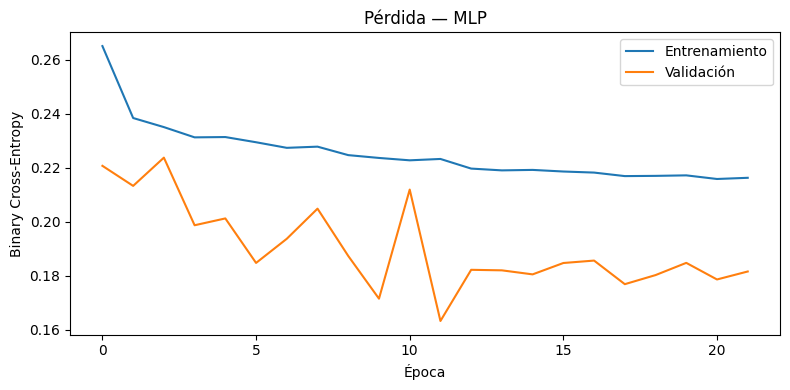

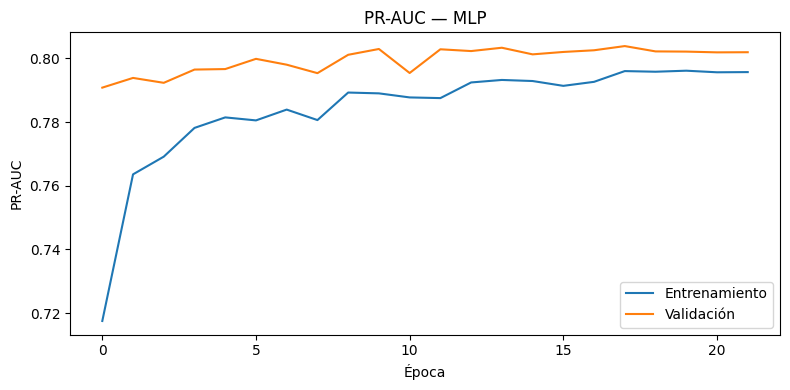

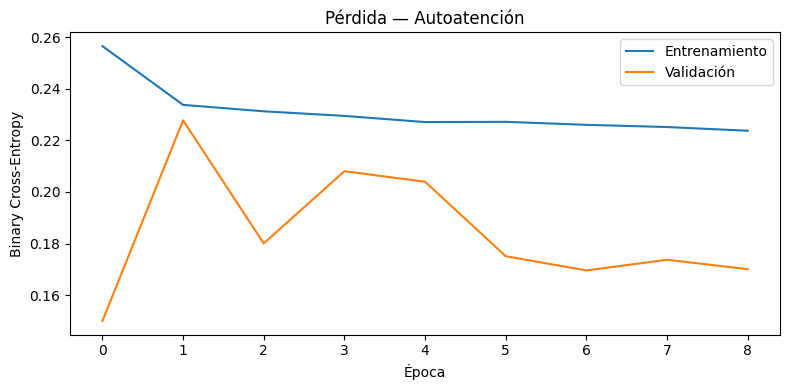

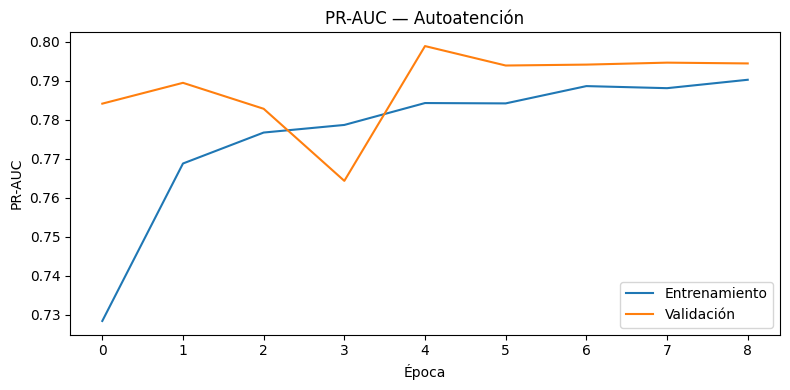

In [27]:

def graficar_historial(history, model_name):
    history_df = pd.DataFrame(history.history)

    plt.figure(figsize=(8, 4))
    plt.plot(history_df["loss"], label="Entrenamiento")
    plt.plot(history_df["val_loss"], label="Validación")
    plt.title(f"Pérdida — {model_name}")
    plt.xlabel("Época")
    plt.ylabel("Binary Cross-Entropy")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(history_df["pr_auc"], label="Entrenamiento")
    plt.plot(history_df["val_pr_auc"], label="Validación")
    plt.title(f"PR-AUC — {model_name}")
    plt.xlabel("Época")
    plt.ylabel("PR-AUC")
    plt.legend()
    plt.tight_layout()
    plt.show()


graficar_historial(history_mlp, "MLP")
graficar_historial(history_attention, "Autoatención")


## Selección del umbral

Las redes generan puntuaciones continuas y necesitan un umbral para convertirlas en clases. En lugar de adoptar automáticamente 0,50, se selecciona sobre validación el punto que maximiza F1 y luego se aplica sin ajustes a prueba.

Los umbrales resultantes son altos —0,9197 para la MLP y 0,9515 para el Self-Attention model— porque el entrenamiento ponderado altera la escala de las salidas. Por ello, estas puntuaciones no deben interpretarse directamente como probabilidades calibradas de abandono. Si el modelo se usara para asignar recursos o activar intervenciones, convendría calibrarlo y elegir el umbral según el costo real de falsos negativos y falsas alarmas.


In [28]:

def encontrar_mejor_umbral(y_true, probabilities):
    precision_values, recall_values, thresholds = precision_recall_curve(
        y_true,
        probabilities,
    )

    # precision y recall tienen un elemento más que thresholds.
    precision_values = precision_values[:-1]
    recall_values = recall_values[:-1]

    f1_values = (
        2 * precision_values * recall_values
        / (precision_values + recall_values + 1e-12)
    )

    best_index = int(np.nanargmax(f1_values))

    return {
        "threshold": float(thresholds[best_index]),
        "precision": float(precision_values[best_index]),
        "recall": float(recall_values[best_index]),
        "f1": float(f1_values[best_index]),
    }


val_prob_mlp = mlp_model.predict(val_ds, verbose=0).ravel()
val_prob_attention = attention_model.predict(val_ds, verbose=0).ravel()

best_mlp = encontrar_mejor_umbral(y_val_np, val_prob_mlp)
best_attention = encontrar_mejor_umbral(
    y_val_np,
    val_prob_attention,
)

print("Mejor umbral MLP:", best_mlp)
print("Mejor umbral atención:", best_attention)


Mejor umbral MLP: {'threshold': 0.9196528196334839, 'precision': 0.8137836604290278, 'recall': 0.7571125265392782, 'f1': 0.7844258688952331}
Mejor umbral atención: {'threshold': 0.9514917135238647, 'precision': 0.8146118721461187, 'recall': 0.7575371549893843, 'f1': 0.7850385038498857}


## Evaluación sobre el conjunto de prueba

La evaluación final utiliza 75.000 registros que no participaron en el ajuste del preprocesamiento, el entrenamiento ni la selección del umbral. Recall cuantifica qué proporción de abandonos se detecta; precision indica qué proporción de alertas corresponde a casos reales; F1 resume el equilibrio entre ambas; PR-AUC evalúa la relación precision-recall a través de todos los umbrales.



===== MLP =====
Umbral: 0.9197
              precision    recall  f1-score   support

 No abandono     0.9926    0.9941    0.9934     72645
    Abandono     0.8103    0.7707    0.7900      2355

    accuracy                         0.9871     75000
   macro avg     0.9014    0.8824    0.8917     75000
weighted avg     0.9869    0.9871    0.9870     75000



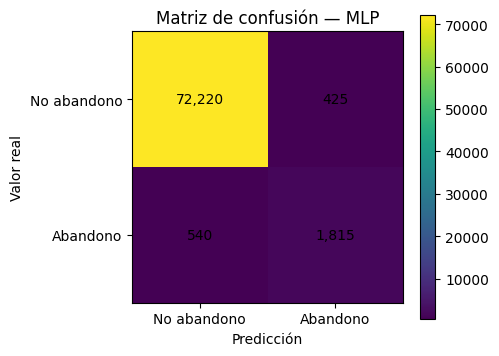


===== Autoatención =====
Umbral: 0.9515
              precision    recall  f1-score   support

 No abandono     0.9925    0.9940    0.9932     72645
    Abandono     0.8051    0.7682    0.7862      2355

    accuracy                         0.9869     75000
   macro avg     0.8988    0.8811    0.8897     75000
weighted avg     0.9866    0.9869    0.9867     75000



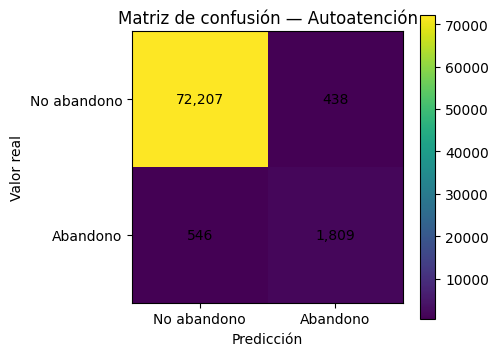

,modelo,umbral,precision,recall,f1,pr_auc,roc_auc
0,MLP,0.919653,0.810268,0.770701,0.789989,0.806382,0.948617
1,Autoatención,0.951492,0.805073,0.768153,0.786180,0.803587,0.949143


In [29]:

def evaluar_modelo(
    model,
    dataset,
    y_true,
    threshold,
    model_name,
):
    probabilities = model.predict(dataset, verbose=0).ravel()
    predictions = (probabilities >= threshold).astype("int32")

    result = {
        "modelo": model_name,
        "umbral": threshold,
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "pr_auc": average_precision_score(y_true, probabilities),
        "roc_auc": roc_auc_score(y_true, probabilities),
    }

    print(f"\n===== {model_name} =====")
    print("Umbral:", round(threshold, 4))
    print(
        classification_report(
            y_true,
            predictions,
            target_names=["No abandono", "Abandono"],
            digits=4,
            zero_division=0,
        )
    )

    matrix = confusion_matrix(y_true, predictions)

    plt.figure(figsize=(5, 4))
    plt.imshow(matrix)
    plt.title(f"Matriz de confusión — {model_name}")
    plt.xlabel("Predicción")
    plt.ylabel("Valor real")
    plt.xticks([0, 1], ["No abandono", "Abandono"])
    plt.yticks([0, 1], ["No abandono", "Abandono"])

    for i in range(2):
        for j in range(2):
            plt.text(
                j,
                i,
                f"{matrix[i, j]:,}",
                ha="center",
                va="center",
            )

    plt.colorbar()
    plt.tight_layout()
    plt.show()

    return result, probabilities, predictions


result_mlp, test_prob_mlp, test_pred_mlp = evaluar_modelo(
    mlp_model,
    test_ds,
    y_test_np,
    best_mlp["threshold"],
    "MLP",
)

result_attention, test_prob_attention, test_pred_attention = evaluar_modelo(
    attention_model,
    test_ds,
    y_test_np,
    best_attention["threshold"],
    "Autoatención",
)

results_table = pd.DataFrame([
    result_mlp,
    result_attention,
]).sort_values("pr_auc", ascending=False)

display(results_table)


## Resultados y discusión

| Modelo | Umbral | Precision | Recall | F1 | PR-AUC | ROC-AUC |
|---|---:|---:|---:|---:|---:|---:|
| MLP | 0,9197 | 0,8103 | 0,7707 | 0,7900 | 0,8064 | 0,9486 |
| Self-Attention model | 0,9515 | 0,8051 | 0,7682 | 0,7862 | 0,8036 | 0,9491 |

La MLP ofrece el mejor equilibrio para identificar la clase minoritaria. De los 2.355 casos reales de abandono en prueba, detecta 1.815 y omite 540; además, produce 425 alertas falsas. El Self-Attention model detecta 1.809, omite 546 y genera 438 alertas falsas. En términos operativos, la MLP recupera seis casos adicionales y evita trece falsas alarmas.

La ventaja cuantitativa es modesta: la MLP supera al Self-Attention model por 0,0028 en PR-AUC, 0,0025 en recall y 0,0038 en F1. El Self-Attention model mejora ROC-AUC por apenas 0,0005, pero esa diferencia no se refleja en las métricas de la clase positiva al umbral elegido. Como no se calcularon intervalos de confianza ni se repitió el experimento con varias semillas, no puede afirmarse que las diferencias sean estadísticamente concluyentes. Sí puede concluirse que el Self-Attention model no demuestra una ventaja práctica en esta ejecución.

La accuracy cercana al 98,7 % debe leerse con cautela: clasificar todos los registros como no abandono ya produciría 96,86 % debido al desbalance. La evidencia relevante es que PR-AUC ronda 0,80, muy por encima de la prevalencia positiva de 0,0314, y que precision y recall se mantienen alrededor de 0,81 y 0,77. El modelo discrimina casos de riesgo con eficacia, pero todavía deja sin detectar aproximadamente el 23 % de los abandonos.

La semejanza entre validación y prueba sugiere una generalización interna estable. Sin embargo, una partición aleatoria evalúa registros de la misma población y puede ser optimista si existen cambios entre periodos o instituciones. Antes de un uso real sería necesario validar con cohortes futuras, centros no vistos y datos externos, además de revisar calibración, equidad entre subgrupos y disponibilidad temporal de las variables.

Por parsimonia, menor costo computacional y desempeño ligeramente superior, la MLP es el modelo recomendado. La decisión final del umbral no debería basarse solo en F1: si omitir un estudiante en riesgo tiene un costo mayor que revisar una alerta falsa, tendría sentido aceptar menor precision para aumentar recall.


## Curva Precision-Recall

La curva Precision-Recall muestra el intercambio entre detectar más abandonos y conservar alertas confiables a medida que cambia el umbral. En este problema resulta más informativa que accuracy porque se concentra en el comportamiento sobre la clase minoritaria. La cercanía de las dos curvas es coherente con las diferencias reducidas de PR-AUC observadas en prueba.


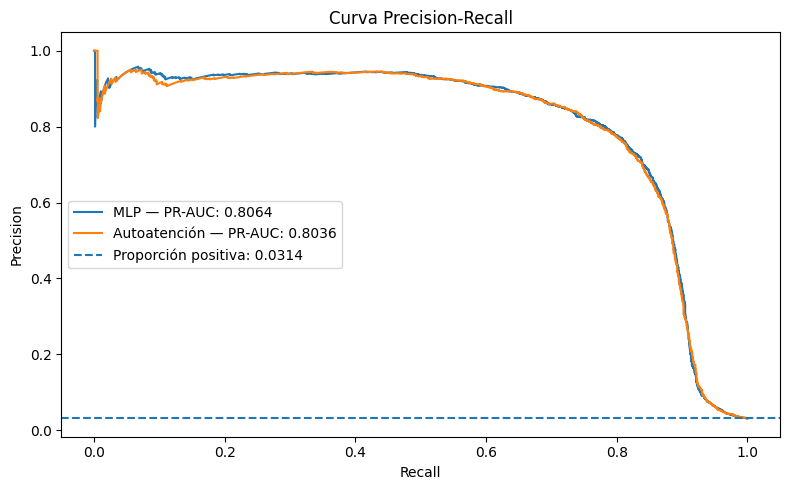

In [30]:

def graficar_precision_recall(y_true, probabilities_by_model):
    plt.figure(figsize=(8, 5))

    for name, probabilities in probabilities_by_model.items():
        precision_values, recall_values, _ = precision_recall_curve(
            y_true,
            probabilities,
        )
        score = average_precision_score(y_true, probabilities)

        plt.plot(
            recall_values,
            precision_values,
            label=f"{name} — PR-AUC: {score:.4f}",
        )

    baseline = float(np.mean(y_true))
    plt.axhline(
        baseline,
        linestyle="--",
        label=f"Proporción positiva: {baseline:.4f}",
    )

    plt.title("Curva Precision-Recall")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.tight_layout()
    plt.show()


graficar_precision_recall(
    y_test_np,
    {
        "MLP": test_prob_mlp,
        "Autoatención": test_prob_attention,
    },
)


## Lectura de los pesos de atención

Los pesos tienen dimensiones correspondientes a registros, cabezas, variables que consultan y variables consultadas. El promedio sobre la muestra, las cabezas y las consultas resume con qué intensidad fue considerada cada variable.

Este resumen es descriptivo, no causal. Un peso alto no demuestra que una variable provoque el abandono ni cuantifica por sí solo su contribución a cada predicción.


Forma de los pesos: (2000, 4, 13, 13)


,variable,atencion_promedio
5,inasistencia_anual_pct,0.086104
3,calificacion_anual,0.076870
9,grado,0.076534
8,sexo,0.076482
7,inseguridad_violencia_plantel,0.076371
6,reportes_disciplinarios,0.076207
10,zona_geografica,0.076159
4,materias_reprobadas,0.076131
12,indice_pobreza,0.076108
0,edad_cronologica,0.076017


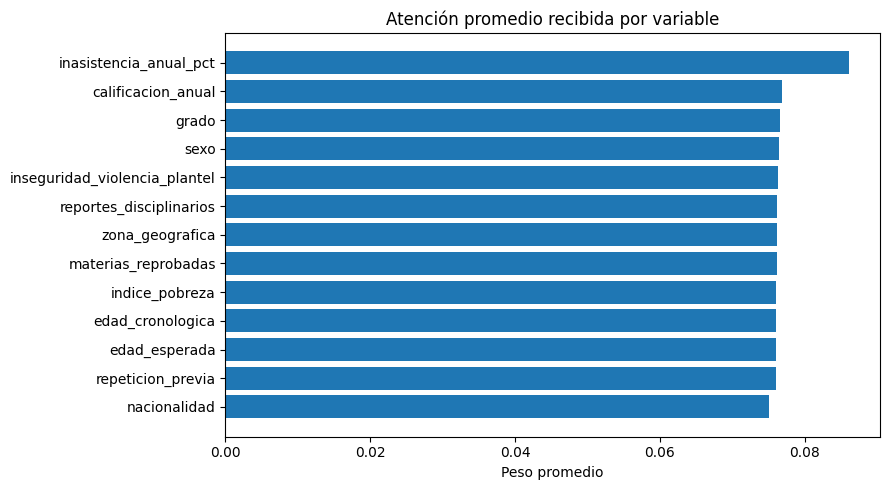

In [31]:

feature_names = numeric_columns + categorical_columns

# Tomamos una muestra pequeña para no usar demasiada memoria.
sample_size = min(2_000, len(y_test_np))
sample_inputs = {
    key: value[:sample_size]
    for key, value in test_inputs.items()
}

attention_scores = attention_explainer.predict(
    sample_inputs,
    batch_size=512,
    verbose=0,
)

print("Forma de los pesos:", attention_scores.shape)

# Promedio sobre: registros, cabezas y variables consulta.
feature_attention = attention_scores.mean(axis=(0, 1, 2))

attention_table = (
    pd.DataFrame({
        "variable": feature_names,
        "atencion_promedio": feature_attention,
    })
    .sort_values("atencion_promedio", ascending=False)
)

display(attention_table)

plot_table = attention_table.sort_values("atencion_promedio")

plt.figure(figsize=(9, max(5, len(plot_table) * 0.35)))
plt.barh(
    plot_table["variable"],
    plot_table["atencion_promedio"],
)
plt.title("Atención promedio recibida por variable")
plt.xlabel("Peso promedio")
plt.tight_layout()
plt.show()


### Interpretación crítica de la atención

Con trece variables, una atención perfectamente uniforme tendría un peso medio aproximado de 1/13 = 0,0769. `inasistencia_anual_pct` alcanza 0,0861, cerca de 0,0092 puntos por encima de esa referencia. `calificacion_anual` obtiene 0,0769 y las demás variables se concentran aproximadamente entre 0,0750 y 0,0765.

La inasistencia es la única variable que se separa de forma visible del patrón casi uniforme, aunque la magnitud sigue siendo moderada. Por tanto, el resultado no respalda una jerarquía fuerte ni explica por sí solo cada decisión del modelo. También es coherente con el resultado predictivo: el mecanismo de atención aprendió una preferencia limitada, pero no consiguió superar a la MLP.

La interpretación debe complementarse con métodos diseñados para atribución, análisis por subgrupos y conocimiento educativo. Sobre todo, no debe transformarse la asociación con inasistencia en una afirmación causal ni en una medida punitiva.


## Conservación del modelo

Para reproducir predicciones futuras se guardan conjuntamente la red, los transformadores numéricos y categóricos, el orden de las columnas, la comparación de modelos, los pesos medios de atención y el umbral seleccionado. Una predicción solo es consistente si utiliza exactamente el mismo preprocesamiento y esquema de variables.


In [32]:

OUTPUT_DIR = Path("salidas_proyecto_desercion")
OUTPUT_DIR.mkdir(exist_ok=True)

attention_model.save(
    OUTPUT_DIR / "modelo_desercion_atencion.keras"
)

joblib.dump(
    {
        "numeric_columns": numeric_columns,
        "categorical_columns": categorical_columns,
        "numeric_imputer": numeric_imputer,
        "numeric_scaler": numeric_scaler,
        "categorical_encoder": categorical_encoder,
        "categorical_vocab_sizes": categorical_vocab_sizes,
        "target": TARGET,
        "id_columns": ID_COLUMNS,
        "threshold": best_attention["threshold"],
    },
    OUTPUT_DIR / "preprocesamiento_desercion.joblib",
)

results_table.to_csv(
    OUTPUT_DIR / "comparacion_modelos.csv",
    index=False,
)

attention_table.to_csv(
    OUTPUT_DIR / "atencion_variables.csv",
    index=False,
)

with open(
    OUTPUT_DIR / "configuracion.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        {
            "seed": SEED,
            "modo_prueba": MODO_PRUEBA,
            "batch_size": BATCH_SIZE,
            "epochs_max": EPOCHS,
            "d_model": D_MODEL,
            "threshold_attention": best_attention["threshold"],
        },
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Archivos guardados en:", OUTPUT_DIR.resolve())
for output_file in OUTPUT_DIR.iterdir():
    print("-", output_file.name)


Archivos guardados en: /content/salidas_proyecto_desercion
- configuracion.json
- preprocesamiento_desercion.joblib
- modelo_desercion_atencion.keras
- comparacion_modelos.csv
- atencion_variables.csv


## Conclusiones y alcance

La MLP es la opción preferida porque iguala o supera al Self-Attention model en las métricas centradas en abandono y requiere una arquitectura más sencilla. El experimento confirma que añadir atención no garantiza una mejora; su utilidad debe demostrarse frente a una línea base sólida.

El desempeño es prometedor, pero no suficiente para automatizar decisiones. Permanecen 540 abandonos no detectados con la MLP y 425 alertas falsas que requerirían revisión. El modelo debería funcionar como apoyo para orientar acompañamiento temprano, nunca como sustituto del criterio profesional ni como fundamento de sanciones.

La evidencia se limita a una partición aleatoria y a una sola ejecución. Una evaluación más robusta debe incluir varias semillas, intervalos de confianza, validación temporal e institucional, calibración de probabilidades y métricas desagregadas por sexo, zona, nacionalidad, pobreza y otros grupos relevantes. También debe verificarse que todas las variables estén disponibles antes del momento en que se pretende intervenir.


## Síntesis metodológica

Se compararon dos arquitecturas neuronales para predecir abandono estudiantil: una MLP utilizada como línea base y un Self-Attention model entre variables. Después de excluir el identificador y la columna constante, se emplearon trece predictores. Las variables numéricas se imputaron con la mediana y se estandarizaron; las categóricas se codificaron y representaron mediante embeddings. Los 500.000 registros se dividieron de forma estratificada en entrenamiento, validación y prueba con proporciones de 70 %, 15 % y 15 %.

El desbalance se trató mediante pesos de clase en la entropía cruzada binaria. Ambos modelos se optimizaron con Adam y utilizaron Dropout, reducción adaptativa de la tasa de aprendizaje y detención temprana basada en PR-AUC de validación. El umbral se eligió en validación maximizando F1 y se aplicó una sola vez al conjunto de prueba. Bajo este protocolo, la MLP obtuvo PR-AUC de 0,8064 y F1 de 0,7900, frente a 0,8036 y 0,7862 para el Self-Attention model.
